In [1]:
import numpy as np
import pandas as pd
import os
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt
from numpy.matlib import repmat
from sklearn.preprocessing import normalize
from PIL import Image

In [4]:
data = []

folder = "final_project/imgs"

for filename in os.listdir(folder):
    img_path = os.path.join(folder, filename)
    if os.path.isdir(img_path):
        continue
    if not filename.lower().endswith((".jpg", ".jpeg")):
        continue
        
    img = Image.open(img_path).convert("L")   # make image gray
    # arr = np.array(img).flatten()             # flatten to 1D vector
    data.append(img)

faces = np.array(data)
print("Data matrix shape:", faces.shape)

Data matrix shape: (405, 1024, 1024)


In [11]:
def viewcolumn(columnvector):
    # viewcolumn(columnvector);
    # Tim Marks 2002
    plt.imshow(meanface, cmap='gray')
    plt.axis('off')


def normc(Mat):
    # normc(M) normalizes the columns of M to a length of 1.
    return normalize(Mat, norm='l2', axis=0)

def viewface(n):
    # to view the nth face (to view 10th, write n=9)
    plt.imshow(faces[n], cmap='gray')
    plt.axis('off')

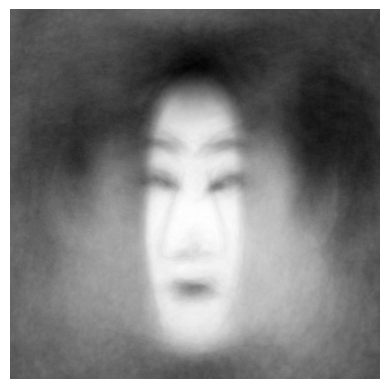

In [12]:
meanface = np.mean(faces,axis=0)

viewcolumn(meanface)

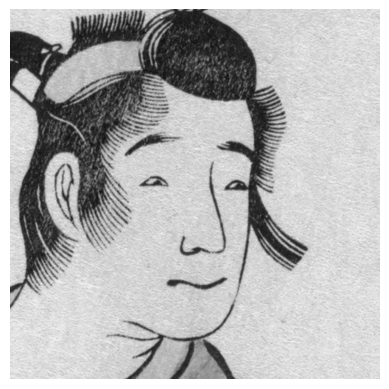

In [14]:
viewface(10)

In [ ]:
def eigsort(V, eigvals):
    # [Vsort,Dsort] = eigsort(V, eigvals)
    #
    # Sorts a matrix eigenvectors and a array of eigenvalues in order 
    # of eigenvalue size, largest eigenvalue first and smallest eigenvalue
    # last.
    #
    # Example usage:
    # di, V = np.linarg.eig(L)
    # Vnew, Dnew = eigsort(V, di)
    #
    # Tim Marks 2002
    
    # Sort the eigenvalues from largest to smallest. Store the sorted
    # eigenvalues in the column vector lambd.
    lohival = np.sort(eigvals)
    lohiindex = np.argsort(eigvals)
    lambd = np.flip(lohival)
    index = np.flip(lohiindex)
    Dsort = np.diag(lambd)
    
    # Sort eigenvectors to correspond to the ordered eigenvalues. Store sorted
    # eigenvectors as columns of the matrix vsort.
    M = np.size(lambd)
    Vsort = np.zeros((M, M))
    for i in range(M):
        Vsort[:,i] = V[:,index[i]]
    return Vsort, Dsort

In [ ]:
A = faces - np.matlib.repmat(meanface, 1, 406)
eigvals, V_old = np.linalg.eig(A.T @ A)
V, D = eigsort(V_old, eigvals)
U = A @ V